In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_

In [2]:
# ─── 1. RECHARGEMENT DES DONNÉES ──────────────────────────
TIFINAGH_PATH = "../data/Tifinagh-MNIST-main/Dataset/train_data"

def load_tifinagh_mnist(root_path):
    images, labels = [], []
    class_names = sorted(os.listdir(root_path), key=lambda x: int(x))
    for label_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(root_path, class_name)
        if not os.path.isdir(class_folder):
            continue
        for img_file in os.listdir(class_folder):
            try:
                img = Image.open(os.path.join(class_folder, img_file)).convert("L")
                img = img.resize((28, 28))
                images.append(np.array(img))
                labels.append(label_idx)
            except:
                pass
    return np.array(images), np.array(labels), class_names

images, labels, class_names = load_tifinagh_mnist(TIFINAGH_PATH)

In [3]:
# ─── 2. NORMALISATION (0-255 → 0-1) ───────────────────────
images_normalized = images / 255.0

print(f"Avant normalisation — min: {images.min()}, max: {images.max()}, mean: {images.mean():.2f}")
print(f"Après normalisation — min: {images_normalized.min():.2f}, max: {images_normalized.max():.2f}, mean: {images_normalized.mean():.4f}")




Avant normalisation — min: 0, max: 255, mean: 26.59
Après normalisation — min: 0.00, max: 1.00, mean: 0.1043


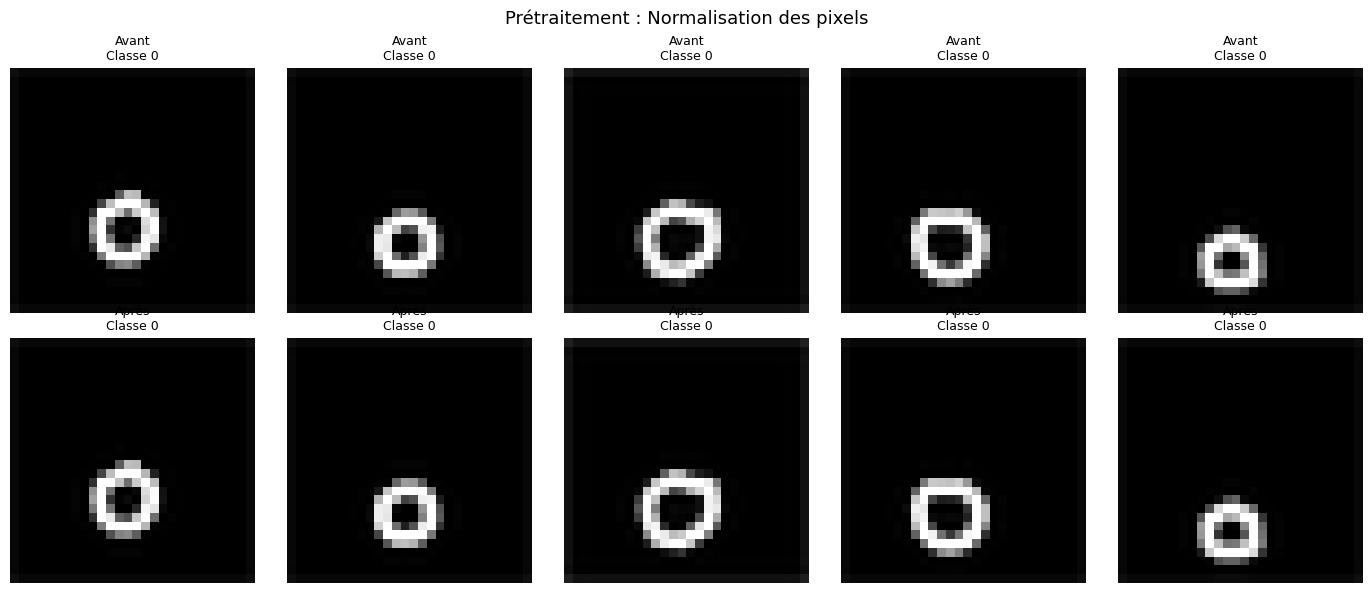

In [5]:
# ─── 3. VISUALISATION AVANT / APRÈS NORMALISATION ─────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i in range(5):
    axes[0, i].imshow(images[i], cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(f"Avant\nClasse {labels[i]}", fontsize=9)
    axes[0, i].axis("off")
    
    axes[1, i].imshow(images_normalized[i], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Après\nClasse {labels[i]}", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Prétraitement : Normalisation des pixels", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/normalisation.png")
plt.show()

In [6]:
# ─── 4. RESHAPE POUR CNN (ajout dimension canal) ──────────
# CNN attend : (nb_images, hauteur, largeur, canaux)
X = images_normalized.reshape(-1, 28, 28, 1)
print(f"\nShape après reshape : {X.shape}")  # (66000, 28, 28, 1)




Shape après reshape : (66000, 28, 28, 1)


In [7]:
# ─── 5. ENCODAGE DES LABELS (one-hot encoding) ────────────
y = to_categorical(labels, num_classes=33)
print(f"Shape des labels    : {y.shape}")   # (66000, 33)
print(f"Exemple label[0]    : {y[0]}")      # vecteur de 0 sauf un 1



Shape des labels    : (66000, 33)
Exemple label[0]    : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [8]:
# ─── 6. SPLIT TRAIN / VALIDATION / TEST ───────────────────
# D'abord : 85% train+val / 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=labels
)

# Ensuite : 70% train / 15% val (sur les 85% restants)
labels_temp = np.array(labels)[: len(X_temp)]
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42
)

print(f"\n=== Split du dataset ===")
print(f"Train      : {X_train.shape[0]} images  (~70%)")
print(f"Validation : {X_val.shape[0]} images  (~15%)")
print(f"Test       : {X_test.shape[0]} images  (~15%)")




=== Split du dataset ===
Train      : 46226 images  (~70%)
Validation : 9874 images  (~15%)
Test       : 9900 images  (~15%)


In [10]:
# ─── 7. SAUVEGARDE ────────────────────────────────────────
np.save("../data/X_train.npy", X_train)
np.save("../data/X_val.npy",   X_val)
np.save("../data/X_test.npy",  X_test)
np.save("../data/y_train.npy", y_train)
np.save("../data/y_val.npy",   y_val)
np.save("../data/y_test.npy",  y_test)

print("\nDonnées sauvegardées dans /data/ ")


Données sauvegardées dans /data/ 
